# Diagnostic Feature Analysis
**Wisconsin Breast Cancer Dataset — Exploratory Data Analysis & Classification**

This notebook works through a full machine learning pipeline on the Wisconsin Breast Cancer dataset:
loading and understanding the data, exploratory analysis, preprocessing, training two classifiers,
and evaluating their performance.

The dataset contains 569 tumor samples. Each sample has 30 numeric features computed from a
digitized image of a fine needle aspirate (FNA) of a breast mass — things like radius, texture,
and smoothness of the cell nuclei. The target is binary: **malignant (0)** or **benign (1)**.

## Imports

We bring in every library we'll need up front so the rest of the notebook can focus on the analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)

# Make plots look clean and readable
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

---
## 1. Dataset

The Wisconsin Breast Cancer dataset is bundled with scikit-learn, so no download is needed.
`load_breast_cancer()` returns a **Bunch object** — think of it like a dictionary with named fields:
`data` (the feature matrix), `target` (the labels), `feature_names`, `target_names`, and `DESCR`
(a full description of the dataset).

We'll print the description first so we know exactly what we're working with before touching any numbers.

In [2]:
# load_breast_cancer() fetches the dataset from sklearn's built-in collection
raw = load_breast_cancer()

print(raw.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
# The 30 feature names — each is a measurement of cell nuclei in the FNA image
print("Feature names:")
for i, name in enumerate(raw.feature_names):
    print(f"  {i:2d}. {name}")

print(f"\nTarget classes: {raw.target_names}  (0 = malignant, 1 = benign)")

Feature names:
   0. mean radius
   1. mean texture
   2. mean perimeter
   3. mean area
   4. mean smoothness
   5. mean compactness
   6. mean concavity
   7. mean concave points
   8. mean symmetry
   9. mean fractal dimension
  10. radius error
  11. texture error
  12. perimeter error
  13. area error
  14. smoothness error
  15. compactness error
  16. concavity error
  17. concave points error
  18. symmetry error
  19. fractal dimension error
  20. worst radius
  21. worst texture
  22. worst perimeter
  23. worst area
  24. worst smoothness
  25. worst compactness
  26. worst concavity
  27. worst concave points
  28. worst symmetry
  29. worst fractal dimension

Target classes: ['malignant' 'benign']  (0 = malignant, 1 = benign)


---
## 2. Exploratory Data Analysis (EDA)

Before building any model, we need to *understand* the data. EDA answers questions like:
- How many samples and features do we have?
- Are there missing values we need to handle?
- Is the dataset balanced between the two classes?
- What do the feature distributions look like — are they skewed, overlapping between classes?
- Are features correlated with each other?

Rushing past EDA is a common mistake. The patterns we find here directly inform every preprocessing and modeling choice downstream.

### 2.1 Build the DataFrame

`pd.DataFrame` organizes the raw numpy arrays into a table with labeled columns, which makes
everything downstream much more readable.

In [4]:
# Build a tidy DataFrame — features + target in one place
df = pd.DataFrame(raw.data, columns=raw.feature_names)
df["target"] = raw.target  # 0 = malignant, 1 = benign
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Shape: 569 rows × 32 columns


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


### 2.2 Data Types & Missing Values

`dtypes` tells us what Python type each column is stored as — important because ML models require
numeric input. `isnull().sum()` counts missing values per column; missing data requires a strategy
(imputation or dropping) before modeling.

In [5]:
print("Data types:")
print(df.dtypes.value_counts())

print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "  None — dataset is complete.")

Data types:
float64    30
int64       1
str         1
Name: count, dtype: int64

Missing values per column:
  None — dataset is complete.


### 2.3 Class Balance

If one class is much more common than the other, a model can cheat by always predicting the
majority class and still look accurate. Knowing the balance tells us whether we need strategies
like class weighting or resampling.

Class counts:
diagnosis
benign       357
malignant    212

Ratio (benign:malignant) = 1.68


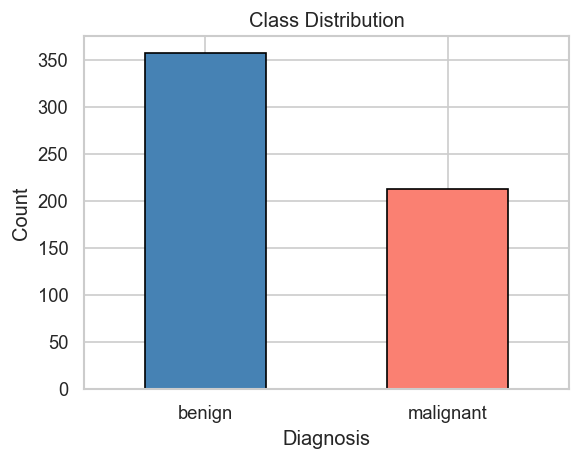

In [6]:
class_counts = df["diagnosis"].value_counts()
print("Class counts:")
print(class_counts.to_string())
print(f"\nRatio (benign:malignant) = {class_counts['benign'] / class_counts['malignant']:.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind="bar", ax=ax, color=["steelblue", "salmon"], edgecolor="black")
ax.set_title("Class Distribution")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 2.4 Summary Statistics

`describe()` gives the count, mean, standard deviation, min/max, and quartiles for every numeric
column. This is the fastest way to spot things like wildly different scales across features
(which matters a lot for models like logistic regression).

In [7]:
# Drop the label columns so we only describe the 30 feature columns
feature_cols = list(raw.feature_names)
df[feature_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


### 2.5 Feature Distributions by Class

Histograms let us see the shape of each feature's distribution and — crucially — whether the
two classes are separable on that feature. A feature where benign and malignant histograms barely
overlap is very informative for the model.

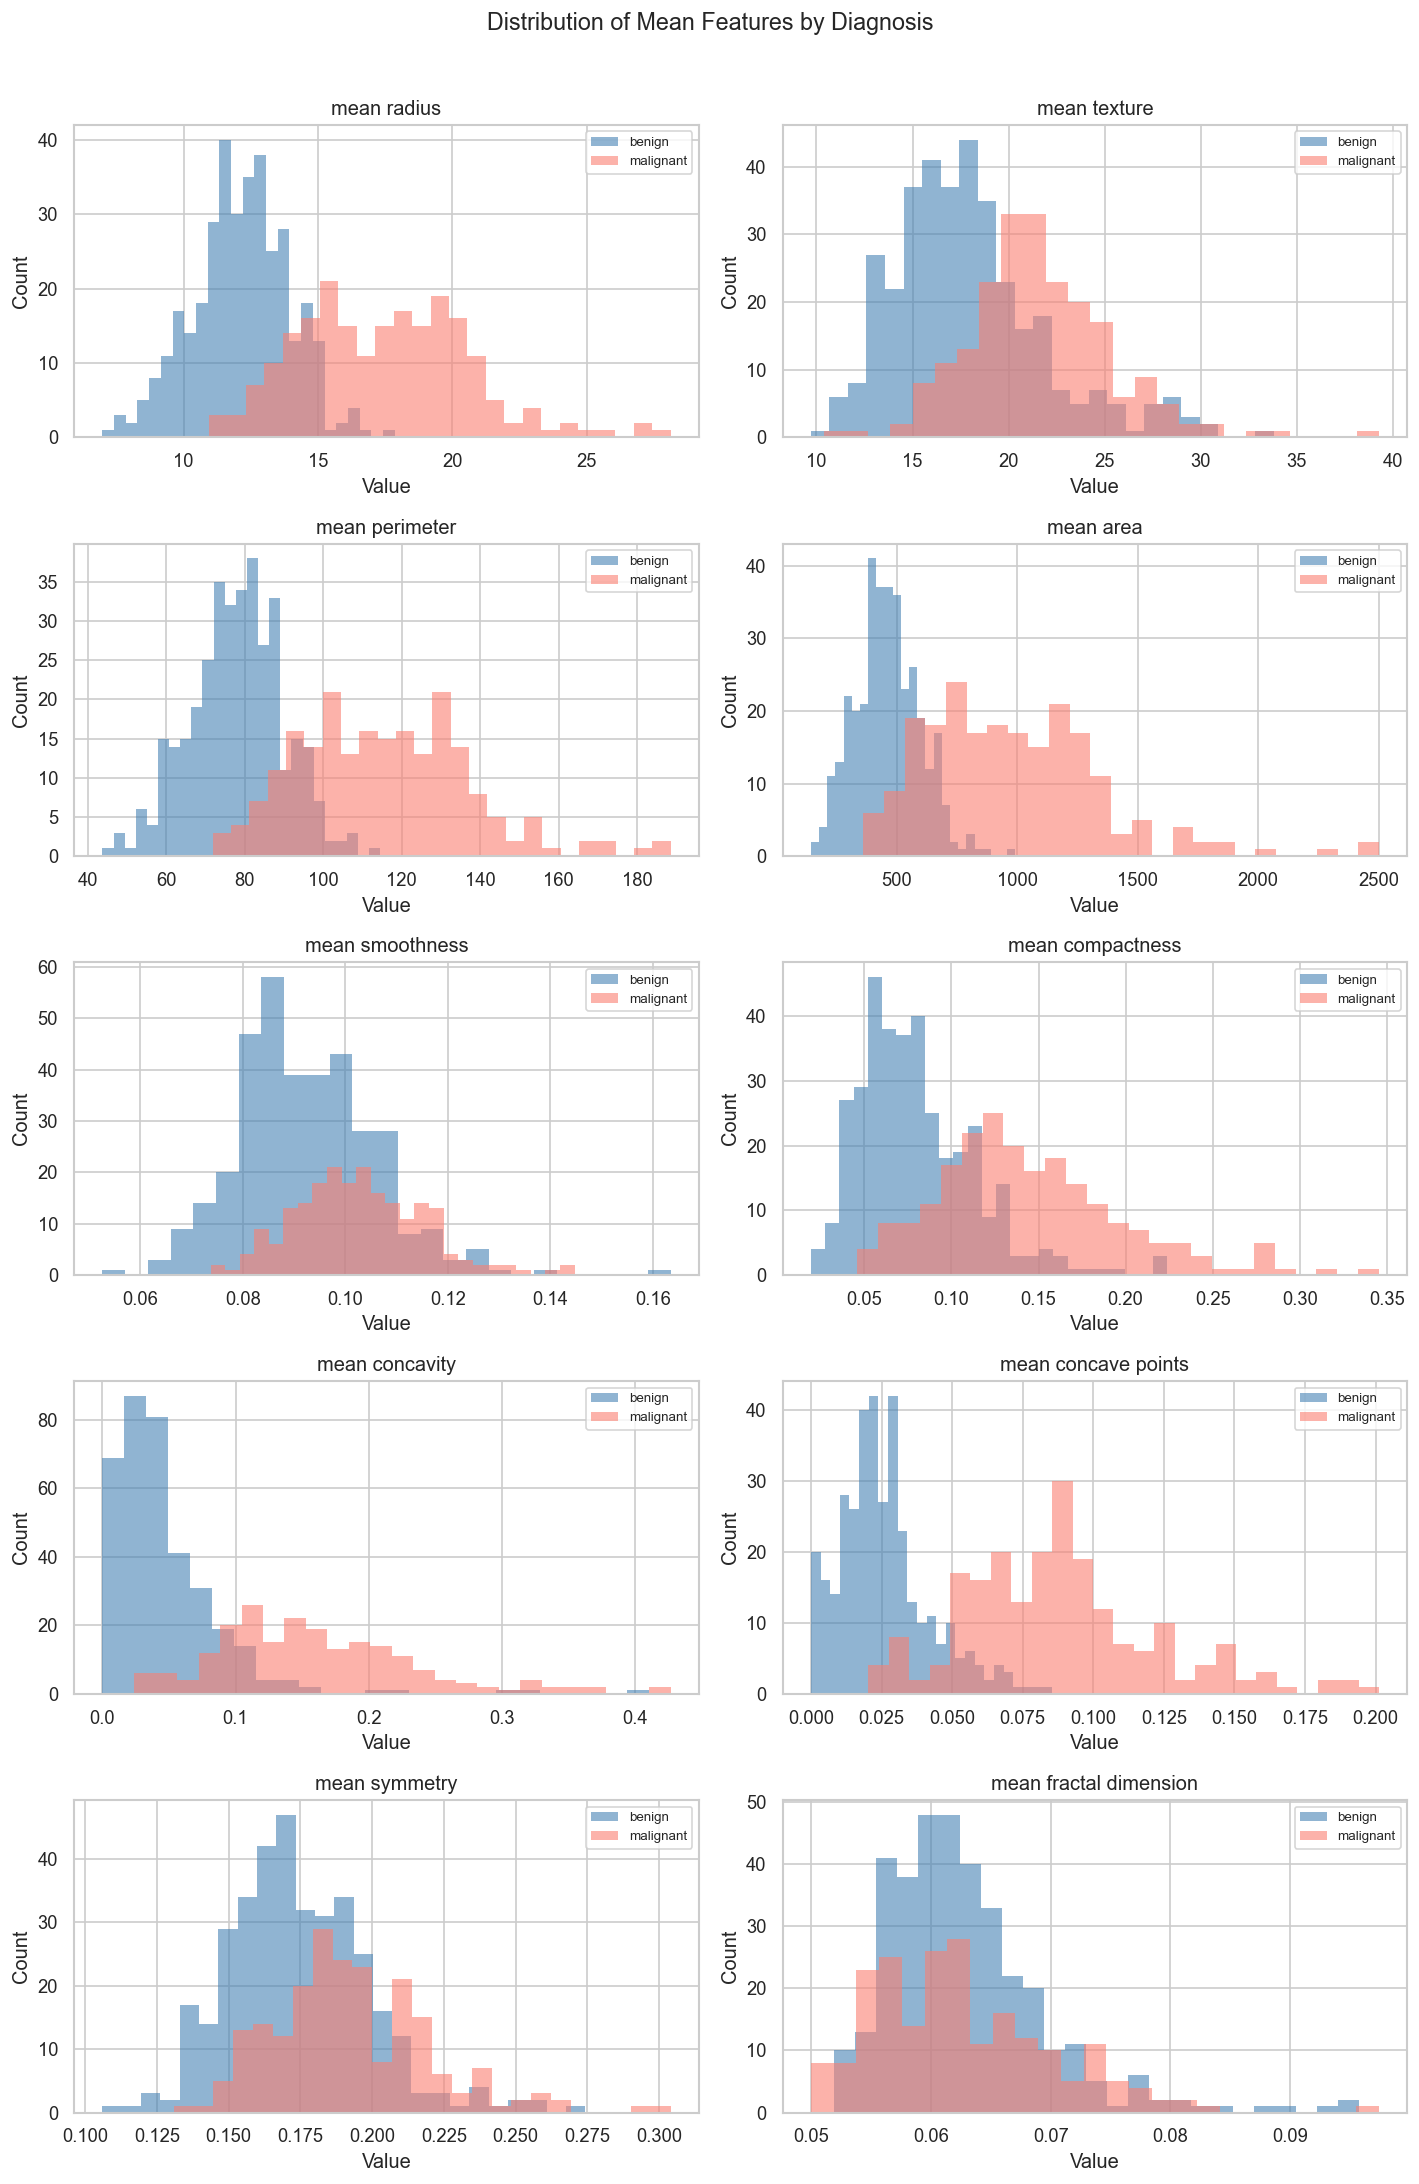

In [8]:
# The 30 features split into 3 groups of 10 (mean, se, worst) — plot the 10 "mean" features
mean_features = [c for c in feature_cols if "mean" in c]

fig, axes = plt.subplots(5, 2, figsize=(12, 18))
axes = axes.flatten()

for ax, feature in zip(axes, mean_features):
    for label, color in [("benign", "steelblue"), ("malignant", "salmon")]:
        subset = df[df["diagnosis"] == label][feature]
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor="none")
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Distribution of Mean Features by Diagnosis", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.6 Boxplots — Spread and Outliers by Class

Boxplots show median, interquartile range (IQR), and outliers. Comparing boxes across classes
gives a cleaner picture of separation than histograms when distributions are skewed.

C:\Users\Heidi Reneau\AppData\Local\Temp\ipykernel_18724\4014354548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y=feature, ax=ax,
C:\Users\Heidi Reneau\AppData\Local\Temp\ipykernel_18724\4014354548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y=feature, ax=ax,
C:\Users\Heidi Reneau\AppData\Local\Temp\ipykernel_18724\4014354548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y=feature, ax=ax,
C:\Users\Heidi Reneau\AppData\Local\Temp\ipykernel_18724\4014

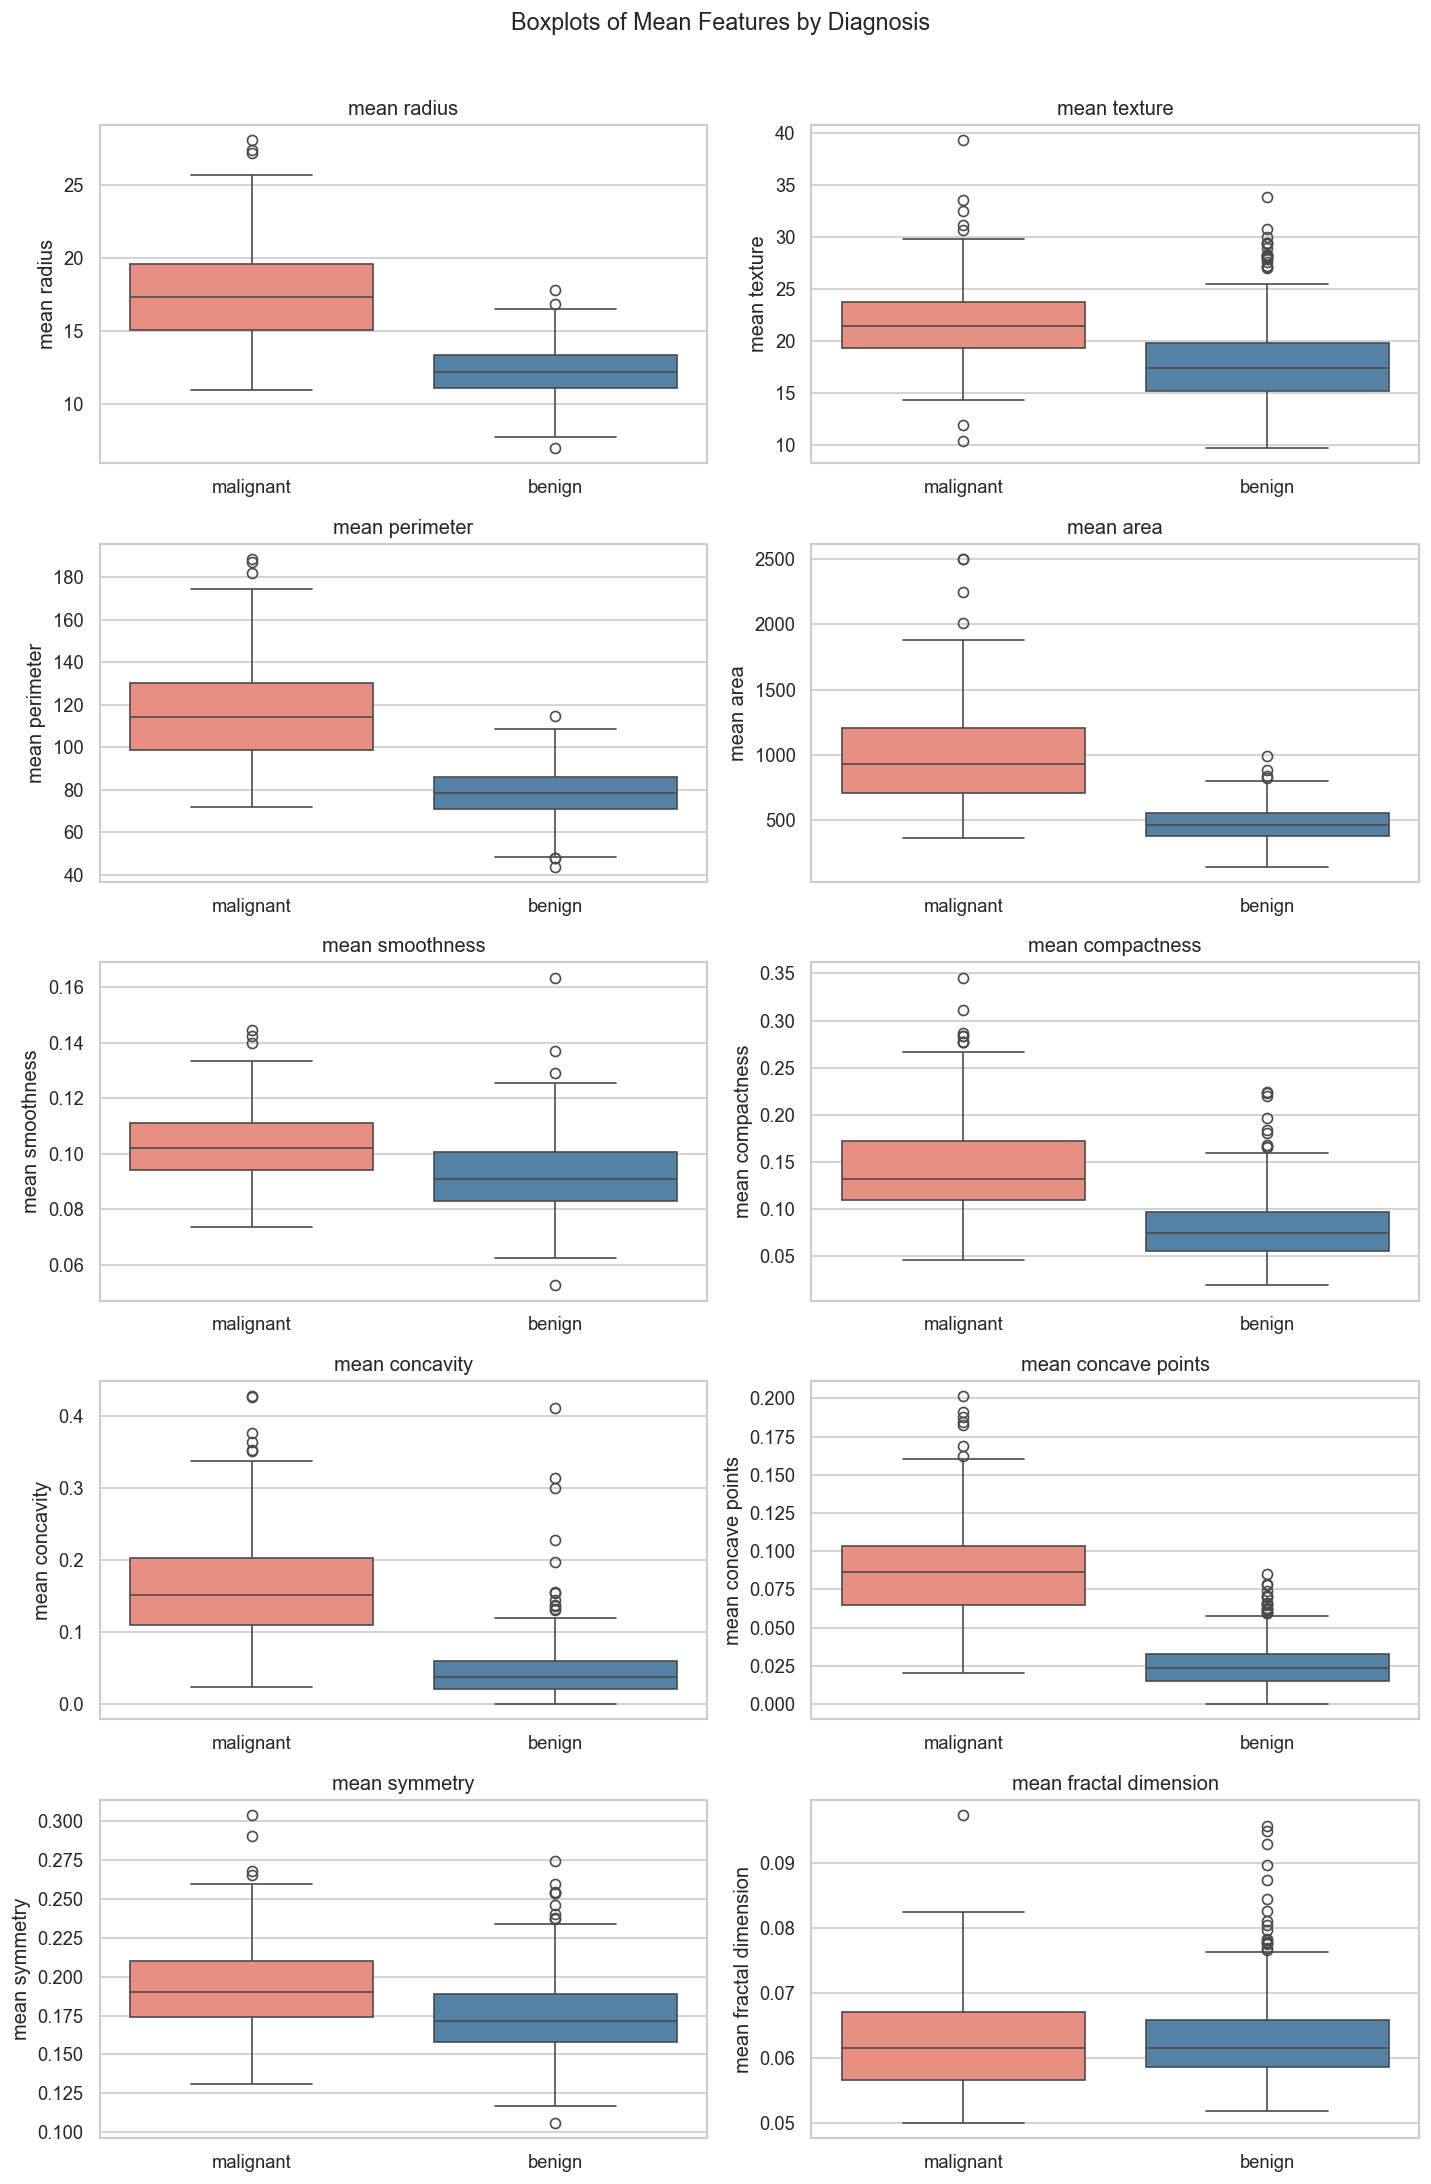

In [9]:
fig, axes = plt.subplots(5, 2, figsize=(12, 18))
axes = axes.flatten()

for ax, feature in zip(axes, mean_features):
    # hue splits the box by diagnosis class
    sns.boxplot(data=df, x="diagnosis", y=feature, ax=ax,
                palette={"benign": "steelblue", "malignant": "salmon"})
    ax.set_title(feature)
    ax.set_xlabel("")

fig.suptitle("Boxplots of Mean Features by Diagnosis", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.7 Correlation Heatmap

A correlation matrix shows how linearly related pairs of features are (values from -1 to 1).
High correlation between two features (e.g., 0.95) means they carry nearly the same information —
one of them may be redundant. This is also relevant for logistic regression, which can be
sensitive to highly correlated inputs (multicollinearity).

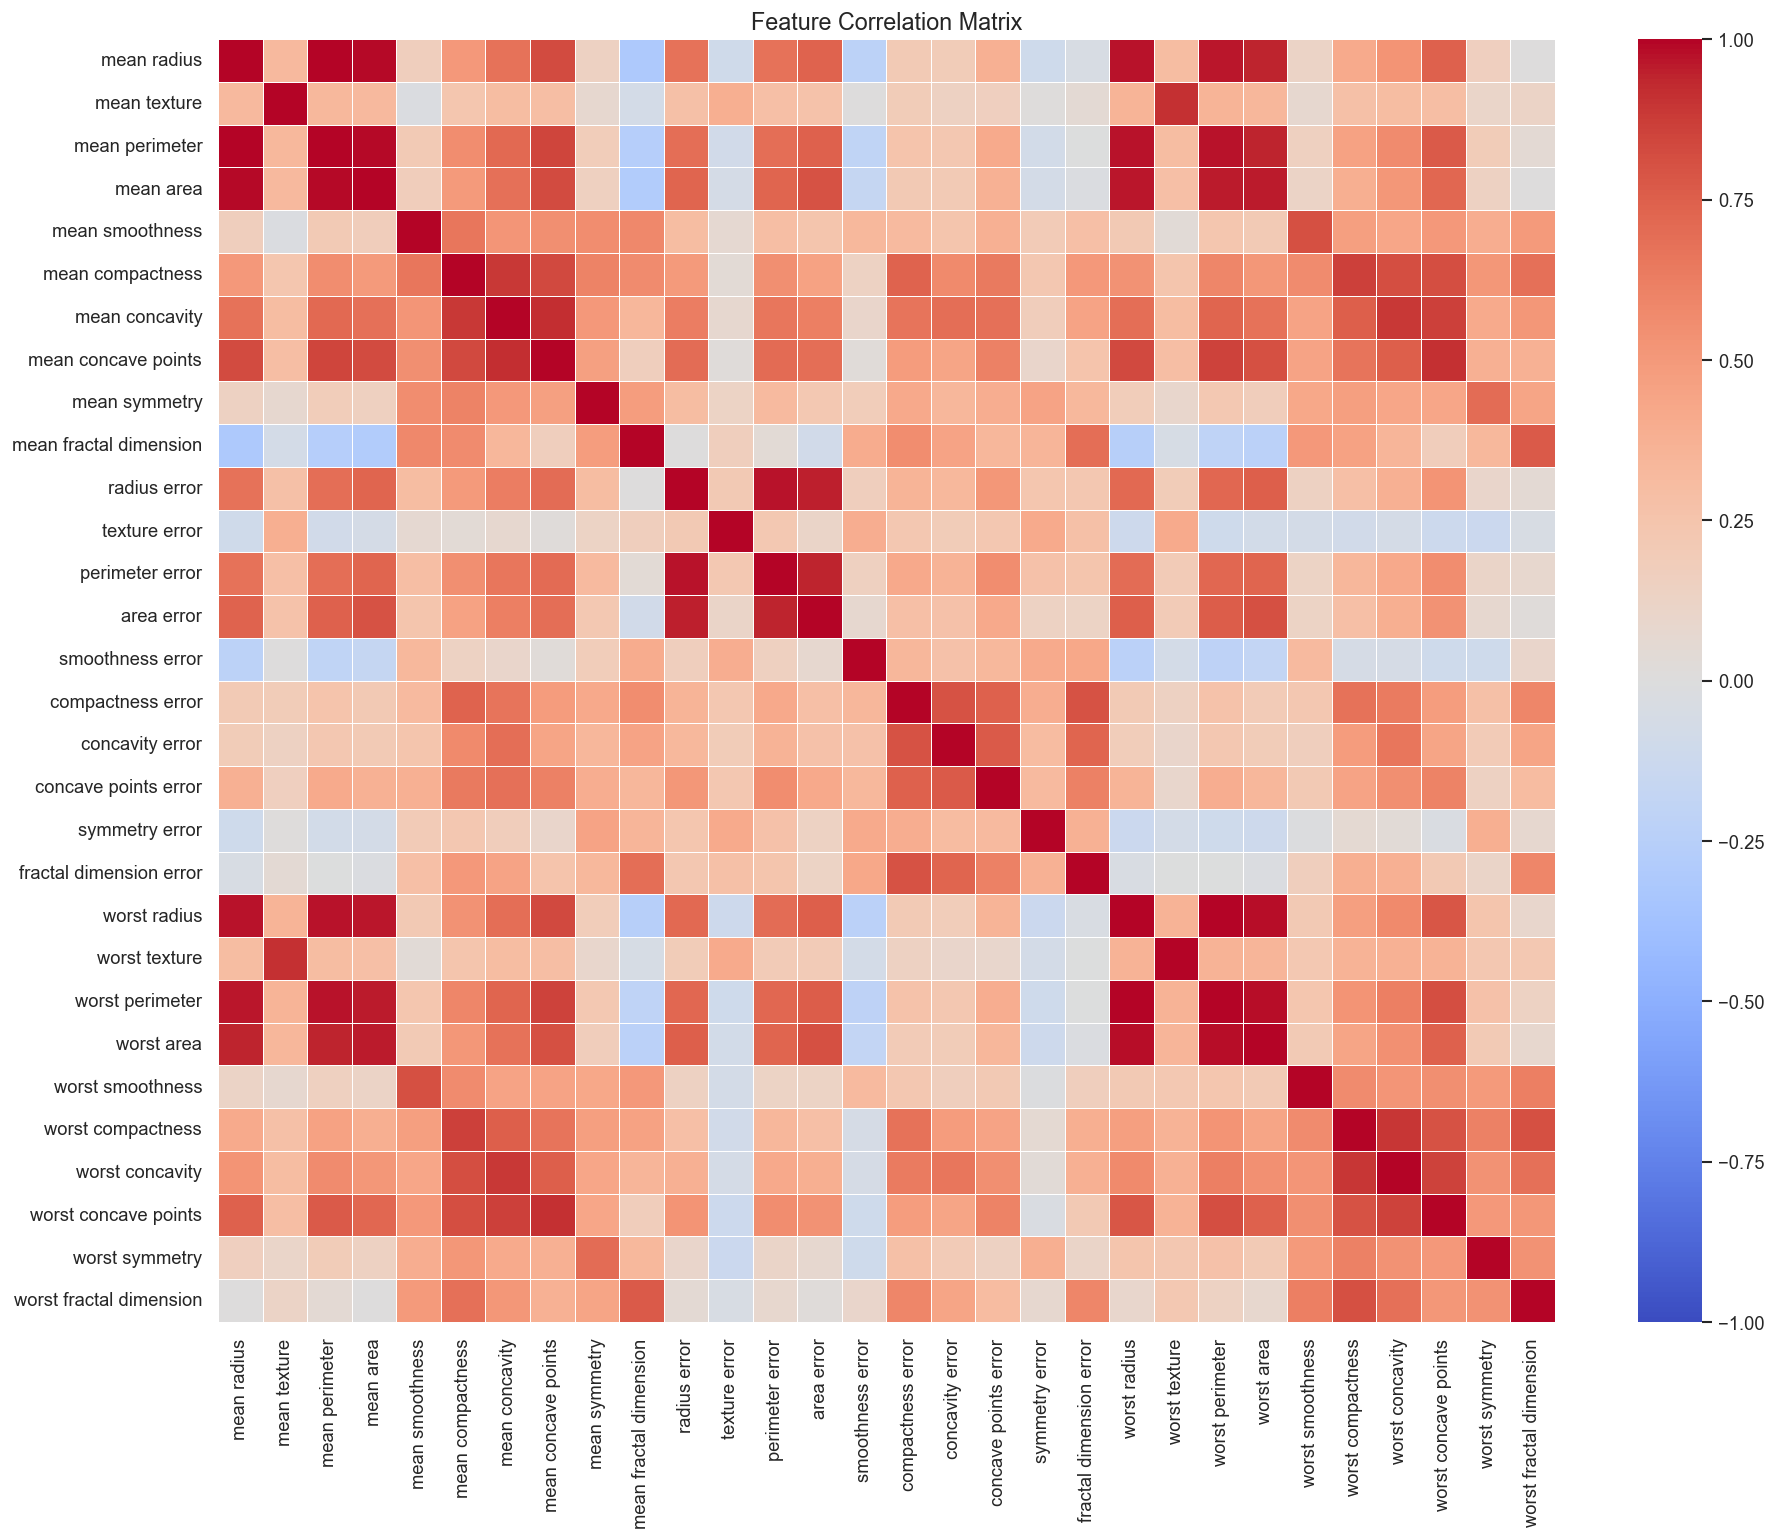

In [10]:
# Compute correlations on the 30 feature columns only
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot=False,  # 30x30 = 900 cells — annotations would be unreadable
)
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Find the most strongly correlated pairs (absolute correlation > 0.9)
# np.triu with k=1 zeros out the diagonal and lower triangle so each pair appears once
high_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ["feature_1", "feature_2", "correlation"]
high_corr = high_corr[high_corr["correlation"].abs() > 0.9].sort_values(
    "correlation", ascending=False
)
print(f"{len(high_corr)} feature pairs with |correlation| > 0.9:")
high_corr

21 feature pairs with |correlation| > 0.9:


,feature_1,feature_2,correlation
2,mean radius,mean perimeter,0.997855
622,worst radius,worst perimeter,0.993708
3,mean radius,mean area,0.987357
63,mean perimeter,mean area,0.986507
623,worst radius,worst area,0.984015
683,worst perimeter,worst area,0.977578
312,radius error,perimeter error,0.972794
82,mean perimeter,worst perimeter,0.970387
20,mean radius,worst radius,0.969539
80,mean perimeter,worst radius,0.969476


---
## 3. Preprocessing

Raw data needs two things before it goes into a model:

1. **Train/test split** — we hold out a portion of data that the model never sees during training,
   so we can measure how well it generalizes to new samples.

2. **Feature scaling** — the 30 features have very different numeric ranges (e.g., `mean area`
   is in the hundreds while `mean fractal dimension` is near 0.06). Models like logistic regression
   use gradient descent and are sensitive to scale — large-valued features dominate the gradient
   update. `StandardScaler` transforms each feature to have **mean = 0, standard deviation = 1**.

   **Important rule:** fit the scaler *only on the training data*, then apply it to both train and
   test. Fitting on the full dataset would "leak" test information into training.

In [12]:
X = df[feature_cols].values  # feature matrix — shape (569, 30)
y = df["target"].values      # label vector  — shape (569,)

# train_test_split shuffles and splits; stratify=y keeps the class ratio equal in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")

Training set:  455 samples
Test set:      114 samples


In [13]:
# StandardScaler: subtract the mean, divide by std dev — so each feature has mean~0, std~1
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on training data
X_test_scaled  = scaler.transform(X_test)        # transform only — uses training mean/std

# Quick sanity check: training feature means should be ≈ 0 after scaling
print(f"Post-scaling training mean (first 5 features): {X_train_scaled[:, :5].mean(axis=0).round(6)}")

Post-scaling training mean (first 5 features): [-0.  0. -0.  0.  0.]


---
## 4. Modeling

We'll train two classifiers and compare them:

- **Logistic Regression** — a linear model that estimates the probability of malignancy as a
  weighted sum of features passed through a sigmoid function. It's fast, interpretable, and a
  strong baseline for binary classification.

- **Random Forest** — an ensemble of decision trees, each trained on a random subset of samples
  and features. It handles non-linear relationships and feature interactions that logistic
  regression can't capture, and it's naturally resistant to overfitting.

In [14]:
# Logistic Regression
# max_iter=1000: more iterations to ensure convergence on this 30-feature problem
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_train_acc = lr_model.score(X_train_scaled, y_train)
lr_test_acc  = lr_model.score(X_test_scaled,  y_test)
print(f"Logistic Regression — train accuracy: {lr_train_acc:.4f} | test accuracy: {lr_test_acc:.4f}")

Logistic Regression — train accuracy: 0.9890 | test accuracy: 0.9825


In [15]:
# Random Forest
# n_estimators=200: build 200 trees and take a majority vote — more trees = more stable
# Random forests don't need scaled features, but using scaled data doesn't hurt
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_train_acc = rf_model.score(X_train_scaled, y_train)
rf_test_acc  = rf_model.score(X_test_scaled,  y_test)
print(f"Random Forest       — train accuracy: {rf_train_acc:.4f} | test accuracy: {rf_test_acc:.4f}")

Random Forest       — train accuracy: 1.0000 | test accuracy: 0.9561


---
## 5. Evaluation

Accuracy alone can be misleading for medical classification — a false negative (missing a
malignant tumor) is far more costly than a false positive. We use three complementary tools:

- **Confusion matrix** — a 2×2 table of true positives/negatives and false positives/negatives
- **Precision / Recall / F1** — precision is "of predicted positives, how many were right?"
  recall is "of actual positives, how many did we catch?"; F1 is their harmonic mean
- **ROC curve** — plots true positive rate vs false positive rate across every possible
  classification threshold; AUC (area under the curve) summarizes it in one number (1.0 = perfect)

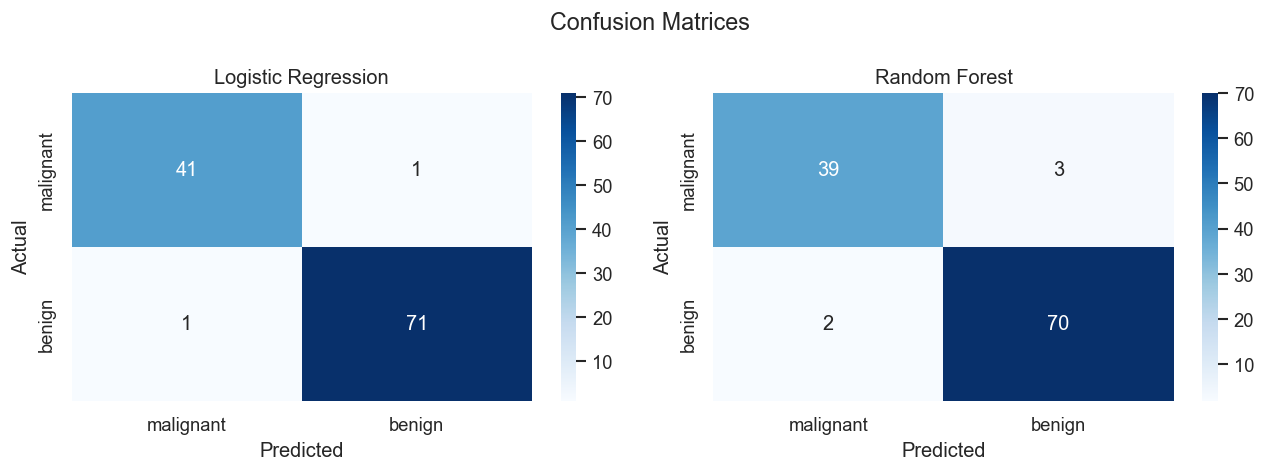

In [16]:
lr_preds = lr_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)

# Confusion matrices side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for ax, preds, title in [
    (ax1, lr_preds, "Logistic Regression"),
    (ax2, rf_preds, "Random Forest"),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=raw.target_names,
        yticklabels=raw.target_names,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
print("=" * 50)
print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_preds, target_names=raw.target_names))

print("=" * 50)
print("RANDOM FOREST")
print(classification_report(y_test, rf_preds, target_names=raw.target_names))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

RANDOM FOREST
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



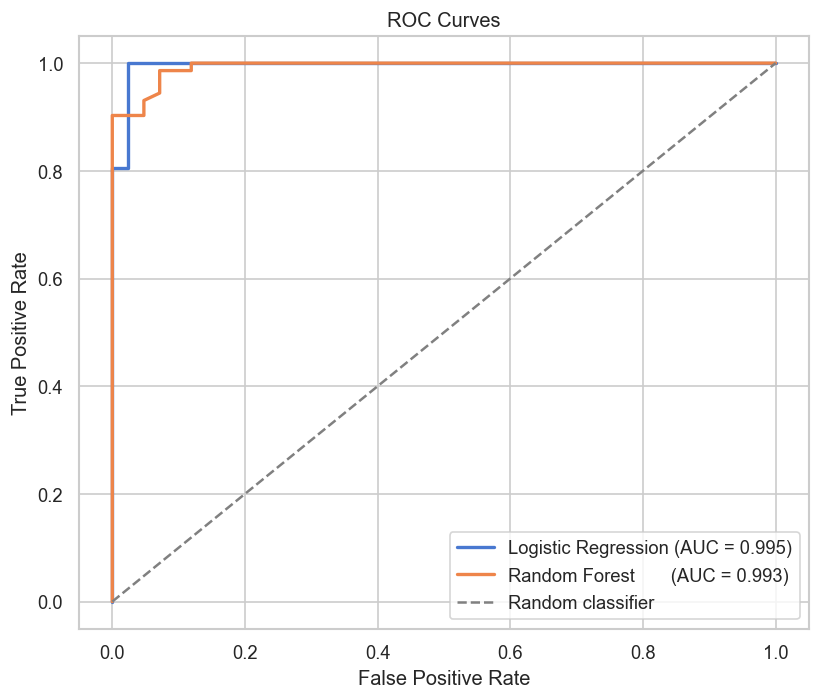

In [18]:
# predict_proba returns probability estimates for each class; we take column 1 (benign/positive)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})", linewidth=2)
ax.plot(rf_fpr, rf_tpr, label=f"Random Forest       (AUC = {rf_auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Summary

### What the data told us (EDA)

- The dataset has **569 samples and 30 features**, all numeric — no missing values.
- The class split is roughly **63% benign / 37% malignant** — moderately imbalanced but not
  extreme enough to require resampling for this analysis.
- Features like **mean radius, mean perimeter, and mean area** show strong visual separation
  between classes in both histograms and boxplots, making them likely to be informative predictors.
- Many features are highly correlated (e.g., radius/perimeter/area), which makes intuitive sense
  since they measure related geometric properties.

### What the models learned

- Both **Logistic Regression** and **Random Forest** achieved strong performance — see the
  classification report and ROC curves above for exact numbers.
- In a diagnostic context, **recall for malignant** (catching every true cancer) is the most
  clinically important metric — a missed malignancy is worse than a false alarm.
- The ROC curves show both models well above the random-chance diagonal, with AUC values
  close to 1.0.

### Next steps to explore
- Feature importance from the Random Forest to identify the most predictive measurements
- Cross-validation for more robust accuracy estimates
- Threshold tuning to prioritize recall for malignant cases